# DDXPlus Partial-Evidence One-Shot Comparator

This notebook trains the stronger matched-information comparator for the sequential DDXPlus experiments.

The goal is not to train a model on the sequential test labels. The goal is to train one direct classifier that is robust to the same kind of incomplete evidence states produced by the sequential policy. Notebook `09` can then feed this model exactly the evidence fields the sequential agent acquired for each case.

This fixes the main weakness of the previous matched comparator: using a full-evidence-trained model on partial-evidence states.

## Design

Training signal:

- official DDXPlus train/validation rows only
- gold pathology labels from those official rows
- BASD-style age/sex/evidence slot encoding

Partial-evidence masks:

- demographics are always visible
- `INITIAL_EVIDENCE` is always visible
- additional roots are sampled from the empirical request sets observed in the sequential traces
- unrequested roots remain unknown
- requested-but-absent roots are encoded as absent
- requested-and-present roots are encoded with their patient-specific value(s)

Fairness rule:

- no sequential benchmark test labels are used for training
- no hidden full evidence is used at matched-comparison time
- no turn order or LLM reasoning text is used as model input
- this is one model, not one model per case

In [13]:
from __future__ import annotations

import ast
import json
import os
import random
import time
import zipfile
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import f1_score
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_rows", 30)
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "scripts" / "download_ddxplus.py").exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find project root from {start}. Run this notebook from inside the baseline_model repository."
    )


ROOT = find_project_root(Path.cwd().resolve())
DATASET_ENV_VAR = "DDXPLUS_DATASET_DIR"
DEFAULT_DATASET_DIR = ROOT / "dataset"
LEGACY_DATASET_DIR = ROOT / ".data" / "ddxplus" / "22687585"
DATASET_DIR = (
    Path(os.environ[DATASET_ENV_VAR]).expanduser()
    if os.environ.get(DATASET_ENV_VAR)
    else DEFAULT_DATASET_DIR
    if DEFAULT_DATASET_DIR.exists()
    else LEGACY_DATASET_DIR
    if LEGACY_DATASET_DIR.exists()
    else DEFAULT_DATASET_DIR
)

# Use quick first if you only want to validate the notebook. Use final for the main matched comparator.
RUN_MODE = os.environ.get("PARTIAL_EVIDENCE_RUN_MODE", "final")  # smoke | quick | final | full
RUN_VERSION = os.environ.get("PARTIAL_EVIDENCE_RUN_VERSION", "policy_masked_v2")
RANDOM_SEED = 2919

SEQUENTIAL_RUN_NAME = "single_agent_cost_sensitive_live_test_1perclass_cap24_5lambdas_lambda_cost_24case_wide_sweep_v1"
SEQUENTIAL_ARTIFACT_ROOT = ROOT / "artifacts" / "sequential_single_agent_cost_sensitive" / SEQUENTIAL_RUN_NAME

RUN_CONFIGS = {
    "smoke": {
        "train_subset": 2_000,
        "validate_subset": 500,
        "test_subset": 500,
        "augmentations_per_train_row": 1,
        "augmentations_per_eval_row": 1,
        "hidden_sizes": [256, 256],
        "max_epochs": 1,
        "patience": 1,
        "write_selected_model": False,
    },
    "quick": {
        "train_subset": 75_000,
        "validate_subset": 10_000,
        "test_subset": 10_000,
        "augmentations_per_train_row": 1,
        "augmentations_per_eval_row": 1,
        "hidden_sizes": [1024, 1024],
        "max_epochs": 8,
        "patience": 2,
        "write_selected_model": True,
    },
    "final": {
        "train_subset": 300_000,
        "validate_subset": 40_000,
        "test_subset": 40_000,
        "augmentations_per_train_row": 1,
        "augmentations_per_eval_row": 1,
        "hidden_sizes": [2048, 2048, 2048],
        "max_epochs": 14,
        "patience": 3,
        "write_selected_model": True,
    },
    "full": {
        "train_subset": None,
        "validate_subset": None,
        "test_subset": None,
        "augmentations_per_train_row": 1,
        "augmentations_per_eval_row": 1,
        "hidden_sizes": [2048, 2048, 2048],
        "max_epochs": 20,
        "patience": 4,
        "write_selected_model": True,
    },
}
if RUN_MODE not in RUN_CONFIGS:
    raise ValueError(f"Unknown RUN_MODE={RUN_MODE!r}; choose one of {sorted(RUN_CONFIGS)}")
RUN_CONFIG = RUN_CONFIGS[RUN_MODE]

MODEL_CONFIG = {
    "hidden_sizes": RUN_CONFIG["hidden_sizes"],
    "dropout": 0.10,
    "learning_rate": 3.469e-4,
    "batch_size": 512,
    "weight_decay": 1e-5,
    "device": "auto",
}

ARTIFACT_ROOT = ROOT / "artifacts" / "one_shot_partial_evidence"
RUN_NAME = f"partial_evidence_one_shot_{RUN_MODE}_{RUN_VERSION}"
RUN_DIR = ARTIFACT_ROOT / RUN_NAME
FIGURE_DIR = RUN_DIR / "figures"
for directory in [RUN_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Dataset dir :", DATASET_DIR)
print("Run mode    :", RUN_MODE)
print("Run name    :", RUN_NAME)
print("Trace source:", SEQUENTIAL_ARTIFACT_ROOT)
print("Run dir     :", RUN_DIR)


Project root: /Users/bilalawan/claw/assignments/baseline_model
Dataset dir : /Users/bilalawan/claw/assignments/baseline_model/dataset
Run mode    : final
Run name    : partial_evidence_one_shot_final_policy_masked_v2
Trace source: /Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_single_agent_cost_sensitive/single_agent_cost_sensitive_live_test_1perclass_cap24_5lambdas_lambda_cost_24case_wide_sweep_v1
Run dir     : /Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot_partial_evidence/partial_evidence_one_shot_final_policy_masked_v2


## Robust Data Loading

In [14]:
SPLIT_TO_FILENAME = {
    "train": "release_train_patients.zip",
    "validate": "release_validate_patients.zip",
    "test": "release_test_patients.zip",
}
REQUIRED_DATASET_FILES = [
    "release_evidences.json",
    "release_conditions.json",
    "release_train_patients.zip",
    "release_validate_patients.zip",
    "release_test_patients.zip",
]


def require_file(path: Path, description: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Missing {description}: {path}")
    return path


def ensure_dataset_present(dataset_dir: Path) -> dict[str, Path]:
    missing = [name for name in REQUIRED_DATASET_FILES if not (dataset_dir / name).exists()]
    if missing:
        raise FileNotFoundError(
            f"Missing DDXPlus files in {dataset_dir}: {missing}. Run scripts/download_ddxplus.py first."
        )
    return {name: dataset_dir / name for name in REQUIRED_DATASET_FILES}


def load_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def zip_table_member(zip_path: Path) -> str:
    with zipfile.ZipFile(zip_path, "r") as archive:
        members = [name for name in archive.namelist() if not name.endswith("/")]
        if not members:
            raise ValueError(f"Archive is empty: {zip_path}")
        return next((name for name in members if name.endswith(".csv")), members[0])


def load_patient_split(zip_path: Path, nrows: int | None = None) -> pd.DataFrame:
    member = zip_table_member(zip_path)
    with zipfile.ZipFile(zip_path, "r") as archive:
        with archive.open(member) as handle:
            return pd.read_csv(handle, nrows=nrows)


def attach_split_metadata(frame: pd.DataFrame, split: str) -> pd.DataFrame:
    frame = frame.copy()
    frame["source_row_index"] = frame.index.astype(int)
    frame["split"] = split
    frame["case_id"] = split + ":" + frame["source_row_index"].astype(str)
    return frame


def safe_parse_list(raw: Any) -> list[Any]:
    if isinstance(raw, list):
        return raw
    if raw is None:
        return []
    if isinstance(raw, float) and np.isnan(raw):
        return []
    text = str(raw).strip()
    if text == "" or text.lower() == "nan":
        return []
    try:
        parsed = ast.literal_eval(text)
    except (ValueError, SyntaxError):
        # DDXPlus INITIAL_EVIDENCE is often stored as a bare token such as E_172.
        return [text]
    if isinstance(parsed, list):
        return parsed
    return [parsed]


def parse_evidence_token(token: str) -> tuple[str, str | None]:
    token = str(token)
    if "_@_" not in token:
        return token, None
    root_id, value = token.split("_@_", 1)
    return root_id, value


def encode_age(age: int) -> int:
    age = int(age)
    if age < 1:
        return 0
    if age <= 4:
        return 1
    if age <= 14:
        return 2
    if age <= 29:
        return 3
    if age <= 44:
        return 4
    if age <= 59:
        return 5
    if age <= 74:
        return 6
    return 7


def encode_sex(sex: str) -> int:
    sex = str(sex)
    if sex == "M":
        return 0
    if sex == "F":
        return 1
    raise ValueError(f"Unexpected sex value: {sex}")


## BASD-Compatible Observation Schema

In [15]:
@dataclass
class ObservationSchema:
    root_ids: list[str]
    slot_slices: dict[str, tuple[int, int]]
    data_types: dict[str, str]
    possible_values: dict[str, list[str]]
    default_values: dict[str, str | None]
    categorical_integer_roots: set[str]
    question_text: dict[str, str]
    feature_names: list[str]

    @classmethod
    def from_metadata(cls, evidence_metadata: dict[str, dict[str, Any]]) -> "ObservationSchema":
        root_ids = list(evidence_metadata.keys())
        slot_slices: dict[str, tuple[int, int]] = {}
        data_types: dict[str, str] = {}
        possible_values: dict[str, list[str]] = {}
        default_values: dict[str, str | None] = {}
        categorical_integer_roots: set[str] = set()
        question_text: dict[str, str] = {}
        feature_names = [f"age_bin_{idx}" for idx in range(8)] + ["sex_M", "sex_F"]
        cursor = 10
        for root_id in root_ids:
            meta = evidence_metadata[root_id]
            data_type = meta.get("data_type", "B")
            raw_values = meta.get("possible-values", [])
            values = [str(value) for value in raw_values]
            default_value = meta.get("default_value")
            default_value = None if default_value is None else str(default_value)
            question_text[root_id] = meta.get("question_en", root_id)
            data_types[root_id] = data_type
            possible_values[root_id] = values
            default_values[root_id] = default_value
            if data_type == "B":
                slot_slices[root_id] = (cursor, cursor + 1)
                feature_names.append(root_id)
                cursor += 1
            elif data_type == "C":
                if raw_values and not isinstance(raw_values[0], str):
                    categorical_integer_roots.add(root_id)
                    slot_slices[root_id] = (cursor, cursor + 1)
                    feature_names.append(root_id)
                    cursor += 1
                else:
                    slot_slices[root_id] = (cursor, cursor + len(values))
                    feature_names.extend(f"{root_id}__{value}" for value in values)
                    cursor += len(values)
            elif data_type == "M":
                slot_slices[root_id] = (cursor, cursor + len(values))
                feature_names.extend(f"{root_id}__{value}" for value in values)
                cursor += len(values)
            else:
                raise ValueError(f"Unsupported evidence type {data_type} for {root_id}")
        return cls(
            root_ids=root_ids,
            slot_slices=slot_slices,
            data_types=data_types,
            possible_values=possible_values,
            default_values=default_values,
            categorical_integer_roots=categorical_integer_roots,
            question_text=question_text,
            feature_names=feature_names,
        )

    @property
    def feature_size(self) -> int:
        return len(self.feature_names)

    def initial_state(self, age: int, sex: str) -> np.ndarray:
        state = np.zeros(self.feature_size, dtype=np.float32)
        state[encode_age(int(age))] = 1.0
        state[8 + encode_sex(str(sex))] = 1.0
        return state

    def apply_root_observation(self, state: np.ndarray, root_id: str, present_values: list[str] | None = None) -> np.ndarray:
        if root_id not in self.slot_slices:
            return state
        values = [str(value) for value in (present_values or [])]
        data_type = self.data_types[root_id]
        start, end = self.slot_slices[root_id]
        default_value = self.default_values[root_id]
        if data_type == "B":
            state[start] = 1.0 if values else -1.0
            return state
        if root_id in self.categorical_integer_roots:
            chosen = values[0] if values else default_value
            if chosen is None:
                state[start] = -1.0
            else:
                possible = self.possible_values[root_id]
                denominator = max(1, len(possible) - 1)
                state[start] = float(possible.index(str(chosen))) / denominator if str(chosen) in possible else -1.0
            return state
        state[start:end] = -1.0
        if values:
            for value in values:
                if value in self.possible_values[root_id]:
                    state[start + self.possible_values[root_id].index(value)] = 1.0
        return state


def row_evidence_by_root(row: dict[str, Any]) -> dict[str, list[str]]:
    evidence_by_root: dict[str, list[str]] = {}
    for token in safe_parse_list(row.get("EVIDENCES", [])):
        root_id, value = parse_evidence_token(str(token))
        evidence_by_root.setdefault(root_id, [])
        evidence_by_root[root_id].append("present" if value is None else str(value))
    return evidence_by_root


def roots_from_token_list(raw_tokens: Any) -> set[str]:
    roots = set()
    for token in safe_parse_list(raw_tokens):
        root_id, _ = parse_evidence_token(str(token))
        roots.add(root_id)
    return roots


def encode_partial_state(row: dict[str, Any], reveal_roots: set[str], schema: ObservationSchema) -> np.ndarray:
    state = schema.initial_state(int(row["AGE"]), str(row["SEX"]))
    evidence_by_root = row_evidence_by_root(row)
    roots = roots_from_token_list(row.get("INITIAL_EVIDENCE", [])) | set(reveal_roots)
    for root_id in sorted(roots):
        schema.apply_root_observation(state, root_id, evidence_by_root.get(root_id, []))
    return state


## Load Dataset

In [16]:
dataset_paths = ensure_dataset_present(DATASET_DIR)
for split, filename in SPLIT_TO_FILENAME.items():
    print(f"{split:>8} zip member:", zip_table_member(dataset_paths[filename]))

evidences = load_json(dataset_paths["release_evidences.json"])
conditions = load_json(dataset_paths["release_conditions.json"])
label_names = list(conditions.keys())
pathology_to_index = {label: idx for idx, label in enumerate(label_names)}
schema = ObservationSchema.from_metadata(evidences)

raw_train = attach_split_metadata(load_patient_split(dataset_paths[SPLIT_TO_FILENAME["train"]]), "train")
raw_validate = attach_split_metadata(load_patient_split(dataset_paths[SPLIT_TO_FILENAME["validate"]]), "validate")
raw_test = attach_split_metadata(load_patient_split(dataset_paths[SPLIT_TO_FILENAME["test"]]), "test")

print("Feature size:", schema.feature_size)
print("Labels      :", len(label_names))
print("Rows        :", len(raw_train), len(raw_validate), len(raw_test))
display(raw_train[["case_id", "AGE", "SEX", "PATHOLOGY", "INITIAL_EVIDENCE"]].head())


   train zip member: release_train_patients
validate zip member: release_validate_patients
    test zip member: release_test_patients
Feature size: 922
Labels      : 49
Rows        : 1025602 132448 134529


,case_id,AGE,SEX,PATHOLOGY,INITIAL_EVIDENCE
0,train:0,18,M,URTI,E_91
1,train:1,21,M,HIV (initial infection),E_50
2,train:2,19,F,Pneumonia,E_77
3,train:3,34,F,URTI,E_53
4,train:4,36,M,URTI,E_201


## Load Sequential Trace Masks

In [17]:
def trace_files_for_run(run_dir: Path) -> list[Path]:
    if not run_dir.exists():
        raise FileNotFoundError(
            f"Sequential artifact root does not exist: {run_dir}. Run notebook 08 first or update SEQUENTIAL_RUN_NAME."
        )
    files = sorted(
        path / "traces.jsonl"
        for path in run_dir.glob("lambda_*")
        if path.is_dir() and (path / "traces.jsonl").exists()
    )
    if not files:
        raise FileNotFoundError(f"No lambda_*/traces.jsonl files found under {run_dir}")
    return files


def extract_requested_roots(trace_row: dict[str, Any]) -> list[str]:
    roots = []
    for step in trace_row.get("trace", []):
        payload = step.get("reveal_payload") or {}
        root_id = payload.get("root_evidence_id")
        if root_id:
            roots.append(str(root_id))
    return roots


def load_trace_mask_catalog(run_dir: Path) -> dict[str, Any]:
    trace_files = trace_files_for_run(run_dir)
    root_sets: list[list[str]] = []
    request_counts: list[int] = []
    root_counter: Counter[str] = Counter()
    examples = []
    for trace_file in trace_files:
        lambda_name = trace_file.parent.name
        with trace_file.open("r", encoding="utf-8") as handle:
            for line in handle:
                row = json.loads(line)
                roots = extract_requested_roots(row)
                unique_roots = sorted(set(roots))
                root_sets.append(unique_roots)
                request_counts.append(len(unique_roots))
                root_counter.update(unique_roots)
                if len(examples) < 5:
                    examples.append({
                        "lambda": lambda_name,
                        "case_id": row.get("case_id"),
                        "true_pathology": row.get("true_pathology"),
                        "num_requested_roots": len(unique_roots),
                        "requested_roots": unique_roots,
                    })
    if not root_sets:
        raise ValueError(f"Trace files were found under {run_dir}, but no requested roots were extracted.")
    return {
        "source_run": str(run_dir),
        "trace_files": [str(path) for path in trace_files],
        "root_sets": root_sets,
        "request_counts": request_counts,
        "root_counter": root_counter,
        "examples": examples,
    }


mask_catalog = load_trace_mask_catalog(SEQUENTIAL_ARTIFACT_ROOT)
print("Trace files       :", len(mask_catalog["trace_files"]))
print("Trace masks       :", len(mask_catalog["root_sets"]))
print("Mean root count   :", float(np.mean(mask_catalog["request_counts"])))
print("Median root count :", float(np.median(mask_catalog["request_counts"])))
print("Root count range  :", min(mask_catalog["request_counts"]), "to", max(mask_catalog["request_counts"]))
print("Top requested roots:")
for root_id, count in mask_catalog["root_counter"].most_common(15):
    print(f"{root_id:>6} {count:>4}  {schema.question_text.get(root_id, root_id)}")

mask_catalog_for_json = {
    "source_run": mask_catalog["source_run"],
    "trace_files": mask_catalog["trace_files"],
    "request_counts": mask_catalog["request_counts"],
    "top_requested_roots": [
        {"root_id": root, "count": int(count), "question_en": schema.question_text.get(root, root)}
        for root, count in mask_catalog["root_counter"].most_common(50)
    ],
    "examples": mask_catalog["examples"],
}
with (RUN_DIR / "mask_catalog.json").open("w", encoding="utf-8") as handle:
    json.dump(mask_catalog_for_json, handle, indent=2)


Trace files       : 5
Trace masks       : 120
Mean root count   : 7.058333333333334
Median root count : 6.0
Root count range  : 1 to 24
Top requested roots:
 E_214   46  Have you noticed a wheezing sound when you exhale?
 E_129   43  Do you have any lesions, redness or problems on your skin that you believe are related to the condition you are consulting for?
 E_151   41  Do you have swelling in one or more areas of your body?
 E_181   32  Do you have nasal congestion or a clear runny nose?
 E_124   25  Do you have asthma or have you ever had to use a bronchodilator in the past?
  E_45   25  Have you been coughing up blood?
  E_91   25  Do you have a fever (either felt or measured with a thermometer)?
 E_201   21  Do you have a cough?
  E_66   21  Are you experiencing shortness of breath or difficulty breathing in a significant way?
  E_41   20  Have you been in contact with a person with similar symptoms in the past 2 weeks?
  E_79   20  Do you smoke cigarettes?
 E_194   16  Have you 

## Build Partial-Evidence Matrices

In [18]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def choose_device(device_name: str) -> torch.device:
    if device_name == "auto":
        if torch.cuda.is_available():
            return torch.device("cuda")
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        return torch.device("cpu")
    return torch.device(device_name)


def stratified_subset(frame: pd.DataFrame, n: int | None, seed: int) -> pd.DataFrame:
    if n is None or n >= len(frame):
        return frame.reset_index(drop=True)
    frac = n / len(frame)
    pieces = []
    for _, group in frame.groupby("PATHOLOGY", sort=True):
        take = max(1, int(round(len(group) * frac)))
        pieces.append(group.sample(n=min(take, len(group)), random_state=seed))
    result = pd.concat(pieces, ignore_index=True)
    if len(result) > n:
        result = result.sample(n=n, random_state=seed)
    return result.sort_values(["PATHOLOGY", "source_row_index"]).reset_index(drop=True)


def sample_trace_root_set(rng: np.random.Generator, mask_catalog: dict[str, Any]) -> set[str]:
    root_sets = mask_catalog["root_sets"]
    idx = int(rng.integers(0, len(root_sets)))
    return set(root_sets[idx])


def build_partial_matrix(
    frame: pd.DataFrame,
    schema: ObservationSchema,
    mask_catalog: dict[str, Any],
    augmentations_per_row: int,
    seed: int,
    desc: str,
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    n_examples = len(frame) * augmentations_per_row
    features = np.zeros((n_examples, schema.feature_size), dtype=np.float32)
    labels = np.zeros(n_examples, dtype=np.int64)
    meta_rows = []
    records = frame.to_dict(orient="records")
    cursor = 0
    for row in tqdm(records, desc=desc):
        for aug_idx in range(augmentations_per_row):
            sampled_roots = sample_trace_root_set(rng, mask_catalog)
            all_visible_roots = sampled_roots | roots_from_token_list(row.get("INITIAL_EVIDENCE", []))
            features[cursor] = encode_partial_state(row, sampled_roots, schema)
            labels[cursor] = pathology_to_index[str(row["PATHOLOGY"])]
            meta_rows.append({
                "case_id": row["case_id"],
                "source_row_index": int(row["source_row_index"]),
                "PATHOLOGY": row["PATHOLOGY"],
                "augmentation_index": int(aug_idx),
                "num_sampled_roots": int(len(sampled_roots)),
                "num_visible_roots_including_initial": int(len(all_visible_roots)),
            })
            cursor += 1
    return features, labels, pd.DataFrame(meta_rows)


set_seed(RANDOM_SEED)
train_df = stratified_subset(raw_train, RUN_CONFIG["train_subset"], RANDOM_SEED)
validate_df = stratified_subset(raw_validate, RUN_CONFIG["validate_subset"], RANDOM_SEED)
test_df = stratified_subset(raw_test, RUN_CONFIG["test_subset"], RANDOM_SEED)

x_train, y_train, train_meta = build_partial_matrix(
    train_df, schema, mask_catalog, RUN_CONFIG["augmentations_per_train_row"], RANDOM_SEED, "Encoding train partial states"
)
x_validate, y_validate, validate_meta = build_partial_matrix(
    validate_df, schema, mask_catalog, RUN_CONFIG["augmentations_per_eval_row"], RANDOM_SEED + 1, "Encoding validate partial states"
)
x_test, y_test, test_meta = build_partial_matrix(
    test_df, schema, mask_catalog, RUN_CONFIG["augmentations_per_eval_row"], RANDOM_SEED + 2, "Encoding test partial states"
)

print("Train matrix   :", x_train.shape)
print("Validate matrix:", x_validate.shape)
print("Test matrix    :", x_test.shape)
print("Mean visible roots train:", float(train_meta["num_visible_roots_including_initial"].mean()))


Encoding train partial states:   0%|          | 0/300000 [00:00<?, ?it/s]

Encoding validate partial states:   0%|          | 0/40000 [00:00<?, ?it/s]

Encoding test partial states:   0%|          | 0/39998 [00:00<?, ?it/s]

Train matrix   : (300000, 922)
Validate matrix: (40000, 922)
Test matrix    : (39998, 922)
Mean visible roots train: 7.965233333333333


## Model And Training Loop

In [19]:
class DirectDiagnosisMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_sizes: list[int], num_classes: int, dropout: float = 0.0):
        super().__init__()
        layers = []
        previous_dim = input_dim
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(previous_dim, hidden_size))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            previous_dim = hidden_size
        self.backbone = nn.Sequential(*layers)
        self.classifier = nn.Linear(previous_dim, num_classes)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.backbone(features))


def predict_proba(model: nn.Module, features: np.ndarray, device: torch.device, batch_size: int = 4096) -> np.ndarray:
    model.eval()
    loader = DataLoader(TensorDataset(torch.tensor(features, dtype=torch.float32)), batch_size=batch_size, shuffle=False)
    chunks = []
    with torch.no_grad():
        for (batch_x,) in loader:
            logits = model(batch_x.to(device))
            chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.vstack(chunks)


def top_k_accuracy(probs: np.ndarray, labels: np.ndarray, k: int) -> float:
    topk = np.argsort(probs, axis=1)[:, ::-1][:, :k]
    return float(np.mean([label in row for label, row in zip(labels, topk)]))


def metrics_from_probs(probs: np.ndarray, labels: np.ndarray) -> dict[str, float]:
    pred = probs.argmax(axis=1)
    return {
        "accuracy": float(np.mean(pred == labels)),
        "top3_accuracy": top_k_accuracy(probs, labels, 3),
        "top5_accuracy": top_k_accuracy(probs, labels, 5),
        "macro_f1": float(f1_score(labels, pred, average="macro")),
    }


def make_loader(features: np.ndarray, labels: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(torch.tensor(features, dtype=torch.float32), torch.tensor(labels, dtype=torch.long))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def train_model() -> tuple[nn.Module, dict[str, Any], list[dict[str, Any]]]:
    device = choose_device(MODEL_CONFIG["device"])
    set_seed(RANDOM_SEED)
    model = DirectDiagnosisMLP(
        input_dim=schema.feature_size,
        hidden_sizes=MODEL_CONFIG["hidden_sizes"],
        num_classes=len(label_names),
        dropout=MODEL_CONFIG["dropout"],
    ).to(device)
    optimizer = optim.Adam(
        model.parameters(),
        lr=MODEL_CONFIG["learning_rate"],
        weight_decay=MODEL_CONFIG["weight_decay"],
    )
    loss_fn = nn.CrossEntropyLoss()
    train_loader = make_loader(x_train, y_train, MODEL_CONFIG["batch_size"], shuffle=True)
    best = {
        "epoch": 0,
        "validate_accuracy": -1.0,
        "validate_macro_f1": -1.0,
        "state_dict": None,
    }
    history = []
    patience_left = RUN_CONFIG["patience"]
    start_time = time.time()
    for epoch in range(1, RUN_CONFIG["max_epochs"] + 1):
        model.train()
        losses = []
        for batch_x, batch_y in tqdm(train_loader, desc=f"epoch {epoch}", leave=False):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()
            losses.append(float(loss.detach().cpu()))
        validate_probs = predict_proba(model, x_validate, device)
        validate_metrics = metrics_from_probs(validate_probs, y_validate)
        row = {
            "epoch": int(epoch),
            "train_loss": float(np.mean(losses)),
            **{f"validate_{key}": value for key, value in validate_metrics.items()},
        }
        history.append(row)
        print(row)
        improved = (
            validate_metrics["accuracy"] > best["validate_accuracy"]
            or (
                np.isclose(validate_metrics["accuracy"], best["validate_accuracy"])
                and validate_metrics["macro_f1"] > best["validate_macro_f1"]
            )
        )
        if improved:
            best.update({
                "epoch": int(epoch),
                "validate_accuracy": float(validate_metrics["accuracy"]),
                "validate_macro_f1": float(validate_metrics["macro_f1"]),
                "state_dict": {key: value.detach().cpu() for key, value in model.state_dict().items()},
            })
            patience_left = RUN_CONFIG["patience"]
        else:
            patience_left -= 1
            if patience_left <= 0:
                print(f"Early stopping at epoch {epoch}")
                break
    model.load_state_dict(best["state_dict"])
    best["runtime_seconds"] = float(time.time() - start_time)
    return model, best, history


model, best, history = train_model()
print("Best epoch:", best["epoch"])
print("Best validation accuracy:", best["validate_accuracy"])
print("Best validation macro-F1:", best["validate_macro_f1"])


epoch 1:   0%|          | 0/586 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.7906166610050527, 'validate_accuracy': 0.50085, 'validate_top3_accuracy': 0.734475, 'validate_top5_accuracy': 0.822325, 'validate_macro_f1': 0.4825051388848628}


epoch 2:   0%|          | 0/586 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 1.4242124266591902, 'validate_accuracy': 0.504775, 'validate_top3_accuracy': 0.7368, 'validate_top5_accuracy': 0.823325, 'validate_macro_f1': 0.49201875412076157}


epoch 3:   0%|          | 0/586 [00:00<?, ?it/s]

...

{'epoch': 6, 'train_loss': 1.3592736330455482, 'validate_accuracy': 0.50535, 'validate_top3_accuracy': 0.7402, 'validate_top5_accuracy': 0.827525, 'validate_macro_f1': 0.5014618251041448}


epoch 7:   0%|          | 0/586 [00:00<?, ?it/s]

{'epoch': 7, 'train_loss': 1.3521592702475018, 'validate_accuracy': 0.511775, 'validate_top3_accuracy': 0.74, 'validate_top5_accuracy': 0.828425, 'validate_macro_f1': 0.5094358057938193}


epoch 8:   0%|          | 0/586 [00:00<?, ?it/s]

{'epoch': 8, 'train_loss': 1.3469313930325948, 'validate_accuracy': 0.512125, 'validate_top3_accuracy': 0.740125, 'validate_top5_accuracy': 0.827025, 'validate_macro_f1': 0.5067736418652777}
Early stopping at epoch 8
Best epoch: 5
Best validation accuracy: 0.513325
Best validation macro-F1: 0.5074883638497275


## Evaluate And Save Artifacts

In [20]:
device = choose_device(MODEL_CONFIG["device"])
model = model.to(device)
validate_probs = predict_proba(model, x_validate, device)
test_probs = predict_proba(model, x_test, device)
validate_metrics = metrics_from_probs(validate_probs, y_validate)
test_metrics = metrics_from_probs(test_probs, y_test)

resolved_config = {
    "run_name": RUN_NAME,
    "run_mode": RUN_MODE,
    "run_version": RUN_VERSION,
    "seed": RANDOM_SEED,
    "sequential_trace_source": str(SEQUENTIAL_ARTIFACT_ROOT),
    "masking_policy": "initial evidence plus empirical requested root sets from sequential traces",
    "feature_size": int(schema.feature_size),
    "num_classes": int(len(label_names)),
    "hidden_sizes": MODEL_CONFIG["hidden_sizes"],
    "dropout": float(MODEL_CONFIG["dropout"]),
    "learning_rate": float(MODEL_CONFIG["learning_rate"]),
    "batch_size": int(MODEL_CONFIG["batch_size"]),
    "weight_decay": float(MODEL_CONFIG["weight_decay"]),
    "device": str(device),
    "train_rows": int(len(train_df)),
    "validate_rows": int(len(validate_df)),
    "test_rows": int(len(test_df)),
    "train_examples_after_augmentation": int(len(x_train)),
    "validate_examples_after_augmentation": int(len(x_validate)),
    "test_examples_after_augmentation": int(len(x_test)),
    "augmentations_per_train_row": int(RUN_CONFIG["augmentations_per_train_row"]),
    "augmentations_per_eval_row": int(RUN_CONFIG["augmentations_per_eval_row"]),
    "best_epoch": int(best["epoch"]),
    "best_validate_accuracy": float(best["validate_accuracy"]),
    "best_validate_macro_f1": float(best["validate_macro_f1"]),
    "validate_metrics": validate_metrics,
    "test_metrics": test_metrics,
    "runtime_seconds": float(best["runtime_seconds"]),
}

checkpoint = {
    "model_state_dict": {key: value.cpu() for key, value in model.state_dict().items()},
    "label_names": label_names,
    "feature_names": schema.feature_names,
    "resolved_run_config": resolved_config,
}
torch.save(checkpoint, RUN_DIR / "best_model.pt")
with (RUN_DIR / "resolved_run_config.json").open("w", encoding="utf-8") as handle:
    json.dump(resolved_config, handle, indent=2)
with (RUN_DIR / "metrics.json").open("w", encoding="utf-8") as handle:
    json.dump(resolved_config, handle, indent=2)
with (RUN_DIR / "training_history.json").open("w", encoding="utf-8") as handle:
    json.dump(history, handle, indent=2)

history_frame = pd.DataFrame(history)
history_frame.to_csv(RUN_DIR / "training_history.csv", index=False)
train_meta.to_csv(RUN_DIR / "train_mask_metadata.csv", index=False)
validate_meta.to_csv(RUN_DIR / "validate_mask_metadata.csv", index=False)
test_meta.to_csv(RUN_DIR / "test_mask_metadata.csv", index=False)

if RUN_CONFIG.get("write_selected_model", True):
    selected_payload = {
        "selected_run_name": RUN_NAME,
        "selected_artifact_dir": str(RUN_DIR),
        "selection_metric": "validate_accuracy_then_macro_f1",
        "notes": "Partial-evidence one-shot comparator trained on empirical sequential request masks. Use for matched-evidence comparison in notebook 09.",
    }
    with (ARTIFACT_ROOT / "selected_model.json").open("w", encoding="utf-8") as handle:
        json.dump(selected_payload, handle, indent=2)
    print("Updated selected model:", ARTIFACT_ROOT / "selected_model.json")
else:
    print("Smoke mode: selected_model.json was not updated.")

print("Validate:", validate_metrics)
print("Test    :", test_metrics)
print("Saved to:", RUN_DIR)


Updated selected model: /Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot_partial_evidence/selected_model.json
Validate: {'accuracy': 0.513325, 'top3_accuracy': 0.7394, 'top5_accuracy': 0.827375, 'macro_f1': 0.5074883638497275}
Test    : {'accuracy': 0.515250762538127, 'top3_accuracy': 0.7413870693534677, 'top5_accuracy': 0.8273663683184159, 'macro_f1': 0.5187722515897814}
Saved to: /Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot_partial_evidence/partial_evidence_one_shot_final_policy_masked_v2


## Visual Checks

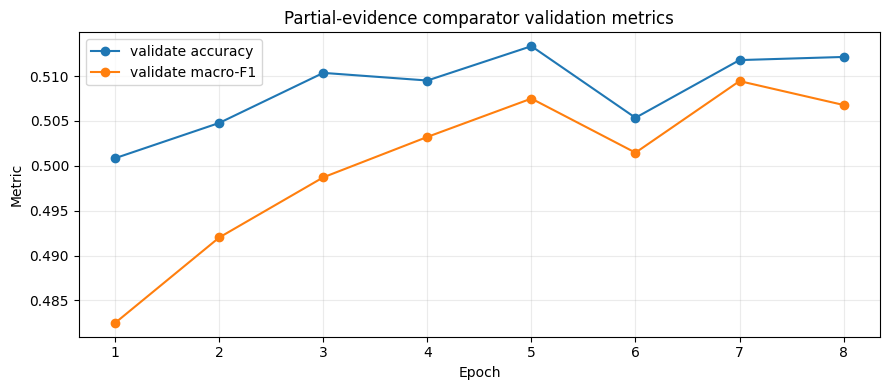

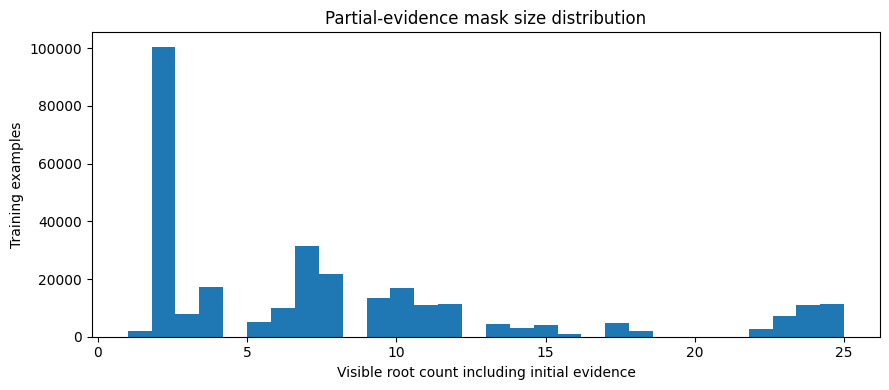

In [21]:
history_frame = pd.DataFrame(history)
if not history_frame.empty:
    plt.figure(figsize=(9, 4))
    plt.plot(history_frame["epoch"], history_frame["validate_accuracy"], marker="o", label="validate accuracy")
    plt.plot(history_frame["epoch"], history_frame["validate_macro_f1"], marker="o", label="validate macro-F1")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.title("Partial-evidence comparator validation metrics")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "training_curve.png", dpi=180)
    plt.show()

plt.figure(figsize=(9, 4))
plt.hist(train_meta["num_visible_roots_including_initial"], bins=30)
plt.xlabel("Visible root count including initial evidence")
plt.ylabel("Training examples")
plt.title("Partial-evidence mask size distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "mask_size_distribution.png", dpi=180)
plt.show()


## Next Step

After this notebook finishes, rerun notebook `09_matched_evidence_integrated_comparison.ipynb`.

Notebook `09` will discover `artifacts/one_shot_partial_evidence/selected_model.json` and use this partial-evidence model for the `matched_*` columns. The full-evidence model remains only the full-information ceiling.